Originally designed for multi-machine distribution across team members' laptops (one scheduler + multiple worker nodes connected over a local network using Dask's distributed framework). Due to time and physical constraints, the implementation was pivoted to a LocalCluster simulation on a single machine. 
The architecture, task distribution logic, Binary Relevance partitioning strategy, and worker code remain identical to a real multi-machine deployment — only the cluster initialization differs. 
To deploy on real machines, replace LocalCluster with Client("<scheduler-ip>:8786") after running `dask scheduler` and `dask worker` on the respective machines

Loading metdata and normalised csv files from milestone 1.

One more thing. 
Upon looking at the dataset again, found out that not only do we have mutliple samples and mutiple input features but also mutiple output labels to predict too.
So now, instead of breaking the input features into batch sizes and then training per ONE label (as we thought there was one output label only),
we will now do batch training by using all input features for each output label class per each classifier.
We will now attempt to train many per-label classifiers in parallel batches across nodes.
This avoids needing one node per output label while keeping Binary Relevance correct.

We have two choices:

Correctness-first (strict BR)
Output labels split across nodes
Full input features assembled for the node before training each assigned label batch
More communication, more correct to BR definition

Scalability-first (approximate)
Output labels split across nodes
Each node uses only local input-feature slice
Less communication, faster, but approximate

Currently doing the first one.

In [1]:

import pandas as pd
import numpy as np
from pathlib import Path
import pickle

from scipy.sparse import load_npz
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Milestone 1 sparse outputs
TRAIN_NPZ       = Path("X_train_normalized.npz")
TEST_NPZ        = Path("X_test_normalized.npz")
TRAIN_META_FILE = Path("train_meta.csv")
TEST_META_FILE  = Path("test_meta.csv")
NORM_FILE       = Path("normalization_params.pkl")
PARTITION_META_FILE = Path("partition_metadata.pkl")

# Validate required files exist
missing = [f for f in [TRAIN_NPZ, TEST_NPZ, TRAIN_META_FILE, TEST_META_FILE] if not f.exists()]
if missing:
    raise FileNotFoundError(
        f"Required Milestone 1 output files missing: {missing}\n"
        "Run milestone1.ipynb first to generate sparse .npz files."
    )

# Load sparse feature matrices
X_sparse      = load_npz(TRAIN_NPZ)       # CSR sparse, shape (n_train, 5000)
X_test_sparse = load_npz(TEST_NPZ)        # CSR sparse, shape (n_test, 5000)

# Load metadata (row_id + labels)
df_train_meta = pd.read_csv(TRAIN_META_FILE)   # columns: row_id, labels
df_test_meta  = pd.read_csv(TEST_META_FILE)    # columns: row_id

# Load normalization scaler and partition metadata
norm_params    = None
partition_meta = None
if NORM_FILE.exists():
    with open(NORM_FILE, "rb") as f:
        norm_params = pickle.load(f)
if PARTITION_META_FILE.exists():
    with open(PARTITION_META_FILE, "rb") as f:
        partition_meta = pickle.load(f)

feature_cols = partition_meta["feature_cols"] if partition_meta else [f"f{i}" for i in range(X_sparse.shape[1])]

print(f"Train sparse shape : {X_sparse.shape}  (nnz={X_sparse.nnz:,})")
print(f"Test  sparse shape : {X_test_sparse.shape}")
print(f"Train metadata rows: {len(df_train_meta)}")
print(f"Number of features : {len(feature_cols)}")
print(f"Normalization params loaded : {norm_params is not None}")
print(f"Partition metadata loaded   : {partition_meta is not None}")


Train sparse shape : (15377, 5000)  (nnz=3,662,025)
Test  sparse shape : (3971, 5000)
Train metadata rows: 15377
Number of features : 5000
Normalization params loaded : True
Partition metadata loaded   : True


Complete output-label target matrix preparation.
This step converts label strings into binary targets and builds the full output-label training matrix for strict milestone execution.

In [9]:

def parse_labels(label_str):
    if pd.isna(label_str):
        return []
    s = str(label_str).strip()
    if s == "":
        return []
    labels = []
    for item in s.split():
        parts = item.split(":")
        try:
            labels.append(int(parts[0]))
        except ValueError:
            continue
    return labels

# X is the sparse feature matrix loaded in the previous cell
X = X_sparse

all_label_lists = df_train_meta["labels"].apply(parse_labels)

# Full label frequency across entire dataset
label_freq = {}
for row_labels in all_label_lists:
    for lbl in row_labels:
        label_freq[lbl] = label_freq.get(lbl, 0) + 1

all_unique_labels = sorted(label_freq.keys())

print(f"Parsed labels for {len(all_label_lists)} training rows")
print(f"Total unique labels found: {len(label_freq)}")
print(f"Label ID range: {min(all_unique_labels)} to {max(all_unique_labels)}")
print(f"Label frequency distribution (top 10): {sorted(label_freq.items(), key=lambda x: -x[1])[:10]}")

# ── Small-scale validation set (top 12 labels only) — for Mustafa's validation ──
TOP_K_LABELS = 12
selected_labels = sorted(label_freq, key=label_freq.get, reverse=True)[:TOP_K_LABELS]

Y_small = pd.DataFrame(index=df_train_meta.index)
for lbl in selected_labels:
    Y_small[f"label_{lbl}"] = all_label_lists.apply(lambda lst: int(lbl in lst))

print(f"\n[Mustafa] Selected top-{TOP_K_LABELS} labels for small-scale validation: {selected_labels}")
print(f"Feature matrix shape: {X.shape}")
print(f"Small-scale target matrix shape: {Y_small.shape}")


Parsed labels for 15377 training rows
Total unique labels found: 3806
Label ID range: 0 to 3992
Label frequency distribution (top 10): [(3902, 1022), (2640, 888), (1996, 763), (3303, 749), (1367, 688), (1848, 679), (882, 612), (3731, 514), (764, 494), (1707, 467)]

[Mustafa] Selected top-12 labels for small-scale validation: [3902, 2640, 1996, 3303, 1367, 1848, 882, 3731, 764, 1707, 1646, 3436]
Feature matrix shape: (15377, 5000)
Small-scale target matrix shape: (15377, 12)


[1/3] Building full binary label matrix for 3806 labels...


C:\Users\786 Computers\AppData\Local\Temp\ipykernel_10140\1857851476.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Y_full[f"label_{lbl}"] = all_label_lists.apply(lambda lst: int(lbl in lst))
C:\Users\786 Computers\AppData\Local\Temp\ipykernel_10140\1857851476.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  Y_full[f"label_{lbl}"] = all_label_lists.apply(lambda lst: int(lbl in lst))
C:\Users\786 Computers\AppData\Local\Temp\ipykernel_10140\1857851476.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usua

[1/3] Full feature matrix shape  : (15377, 5000)
[1/3] Full label matrix shape    : (15377, 3806)
[1/3] Feature-label separation complete.

[2/3] Computing output label distribution...
      Total labels: 3806
      Most frequent label: label_3902 (1022 samples)
      Least frequent label: label_402 (1 samples)
      Mean samples per label: 21.4
      Median samples per label: 5.0

[3/3] Plotting output label distribution across full dataset...


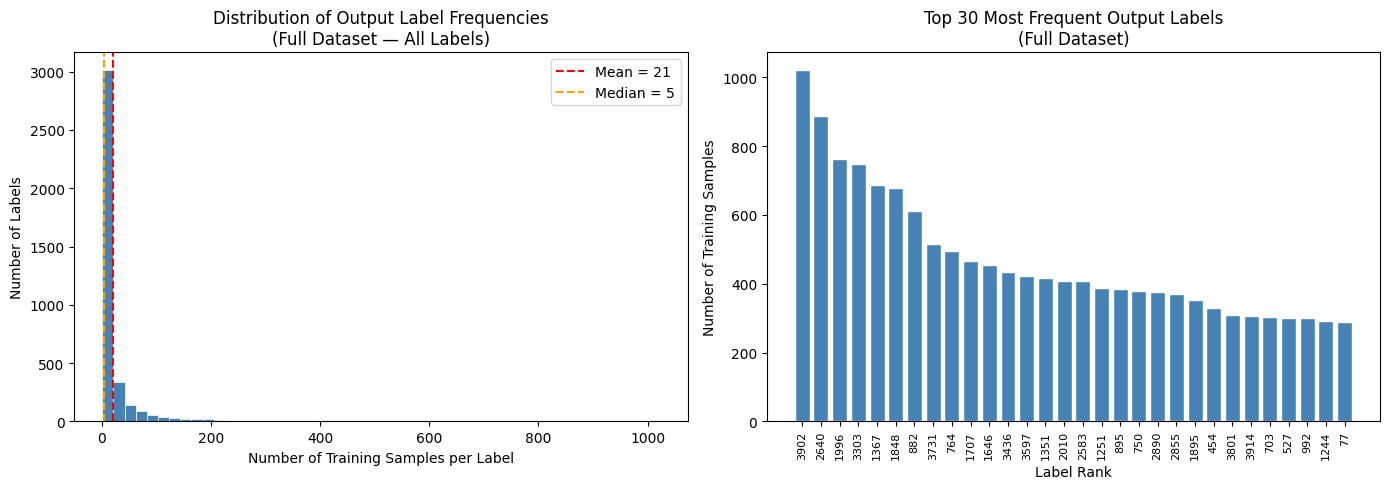

Label distribution plot saved as: output_label_distribution.png


In [10]:

# ── Full feature-label separation across ALL labels ──
import matplotlib.pyplot as plt

# Build full binary target matrix for ALL unique labels
print(f"[1/3] Building full binary label matrix for {len(all_unique_labels)} labels...")
Y_full = pd.DataFrame(index=df_train_meta.index)
for lbl in all_unique_labels:
    Y_full[f"label_{lbl}"] = all_label_lists.apply(lambda lst: int(lbl in lst))

print(f"[1/3] Full feature matrix shape  : {X.shape}")
print(f"[1/3] Full label matrix shape    : {Y_full.shape}")
print(f"[1/3] Feature-label separation complete.")

# Distribution of output labels across the full dataset
print(f"\n[2/3] Computing output label distribution...")
label_counts = pd.Series({f"label_{lbl}": cnt for lbl, cnt in label_freq.items()})
label_counts = label_counts.sort_values(ascending=False)

print(f"      Total labels: {len(label_counts)}")
print(f"      Most frequent label: {label_counts.idxmax()} ({label_counts.max()} samples)")
print(f"      Least frequent label: {label_counts.idxmin()} ({label_counts.min()} samples)")
print(f"      Mean samples per label: {label_counts.mean():.1f}")
print(f"      Median samples per label: {label_counts.median():.1f}")

# Plot distribution of ALL output labels
print(f"\n[3/3] Plotting output label distribution across full dataset...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of label frequencies
axes[0].hist(label_counts.values, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title("Distribution of Output Label Frequencies\n(Full Dataset — All Labels)", fontsize=12)
axes[0].set_xlabel("Number of Training Samples per Label")
axes[0].set_ylabel("Number of Labels")
axes[0].axvline(label_counts.mean(), color='red', linestyle='--', label=f"Mean = {label_counts.mean():.0f}")
axes[0].axvline(label_counts.median(), color='orange', linestyle='--', label=f"Median = {label_counts.median():.0f}")
axes[0].legend()

# Right: top-30 labels by frequency (bar chart)
top30 = label_counts.head(30)
axes[1].bar(range(len(top30)), top30.values, color='steelblue', edgecolor='white')
axes[1].set_title("Top 30 Most Frequent Output Labels\n(Full Dataset)", fontsize=12)
axes[1].set_xlabel("Label Rank")
axes[1].set_ylabel("Number of Training Samples")
axes[1].set_xticks(range(len(top30)))
axes[1].set_xticklabels([lbl.replace("label_","") for lbl in top30.index], rotation=90, fontsize=8)

plt.tight_layout()
plt.savefig("output_label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Label distribution plot saved as: output_label_distribution.png")


Defining the Binary Classifier as a class so it can be reused.

In [4]:
class BinaryClassifier:
    def __init__(self, C=1.0, max_iter=1000, class_weight="balanced", random_state=42):
        self.C = C
        self.max_iter = max_iter
        self.class_weight = class_weight
        self.random_state = random_state
        self.model = LogisticRegression(
            C=self.C,
            max_iter=self.max_iter,
            class_weight=self.class_weight,
            solver="liblinear",
            random_state=self.random_state,
        )

    def fit(self, X_train, y_train):
        self.model.fit(X_train, y_train)
        return self

    def predict(self, X_eval):
        return self.model.predict(X_eval)

    def predict_proba(self, X_eval):
        if hasattr(self.model, "predict_proba"):
            return self.model.predict_proba(X_eval)[:, 1]
        return None

print("BinaryClassifier class ready")

BinaryClassifier class ready


Per-label model training with class balancing.
This step splits input/target data and trains one binary model per output label.

In [5]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y_small,
    test_size=0.2,
    random_state=42,
)

label_models = {}
for col in Y_train.columns:
    y_col = Y_train[col].values

    # Skip labels with single-class training data
    if len(np.unique(y_col)) < 2:
        continue

    clf = BinaryClassifier(C=1.0, max_iter=1000, class_weight="balanced", random_state=42)
    clf.fit(X_train, y_col)
    label_models[col] = clf

print(f"Validation split: X_train={X_train.shape}, X_val={X_val.shape}")
print(f"Models trained: {len(label_models)} / {Y_train.shape[1]}")

Validation split: X_train=(12301, 5000), X_val=(3076, 5000)
Models trained: 12 / 12


This step runs small-scale validation and reports per-label and average metrics for baseline implementation.

In [6]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, log_loss

rows = []
for col, clf in label_models.items():
    y_true = Y_val[col].values
    y_pred = clf.predict(X_val)
    y_prob = clf.predict_proba(X_val)

    report = {
        "label": col,
        "support_pos": int(y_true.sum()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    if y_prob is not None and len(np.unique(y_true)) > 1:
        report["log_loss"] = float(log_loss(y_true, y_prob, labels=[0, 1]))
    else:
        report["log_loss"] = np.nan

    rows.append(report)

metrics_df = pd.DataFrame(rows).sort_values("f1", ascending=False)

if not metrics_df.empty:
    print("Per-label metrics (top rows):")
    display(metrics_df.head(10))

    avg_metrics = metrics_df[["accuracy", "precision", "recall", "f1", "log_loss"]].mean(numeric_only=True)
    print("Average validation metrics across trained labels:")
    print(avg_metrics)
else:
    print("No valid label models were trained.")

Per-label metrics (top rows):


,label,support_pos,accuracy,precision,recall,f1,log_loss
2,label_1996,163,0.989272,0.877907,0.926380,0.901493,0.119194
6,label_882,120,0.960663,0.497696,0.900000,0.640950,0.218061
0,label_3902,199,0.871586,0.320513,0.879397,0.469799,0.340328
5,label_1848,140,0.913524,0.325000,0.835714,0.468000,0.296998
3,label_3303,164,0.895319,0.317130,0.835366,0.459732,0.292624
1,label_2640,182,0.862484,0.277264,0.824176,0.414938,0.349134
4,label_1367,129,0.894018,0.261501,0.837209,0.398524,0.300475
11,label_3436,84,0.870286,0.136259,0.702381,0.228240,0.350486
8,label_764,106,0.864434,0.139211,0.566038,0.223464,0.386319
7,label_3731,85,0.888492,0.133523,0.552941,0.215103,0.405895


Average validation metrics across trained labels:
accuracy     0.893097
precision    0.290815
recall       0.749137
f1           0.397086
log_loss     0.319021
dtype: float64


Strict distributed training:
Reconstructing the complete input feature matrix from partition files, then prepares output-label batches and the distributed cluster/client.

In [7]:

import json
import time
from pathlib import Path

from scipy.sparse import load_npz, hstack
from dask.distributed import Client, LocalCluster, as_completed

MODELS_DIR = Path("models_node_level")
MODELS_DIR.mkdir(exist_ok=True)

partition_paths = []
if isinstance(partition_meta, dict) and "partitions" in partition_meta:
    partition_paths = [p["path"] for p in partition_meta["partitions"]]

num_nodes = int(partition_meta.get("num_nodes", 4)) if isinstance(partition_meta, dict) else 4
if not partition_paths:
    partition_paths = [str(Path("partitions") / f"partition_{i}.npz") for i in range(num_nodes)]

# Strict mode: rebuild full sparse feature matrix from vertical partition shards
# Each partition_i.npz is a column slice — horizontally stack them back together
print("Loading sparse partition shards ...")
shards = [load_npz(path) for path in partition_paths]
print(f"  Loaded {len(shards)} shards, shapes: {[s.shape for s in shards]}")

# Verify all shards have same number of rows
base_rows = shards[0].shape[0]
for i, shard in enumerate(shards[1:], start=1):
    if shard.shape[0] != base_rows:
        raise ValueError(f"Row count mismatch in partition {i}: expected {base_rows}, got {shard.shape[0]}")

# Horizontally stack sparse shards → full feature matrix (still sparse)
X_full = hstack(shards, format="csr")

# Input-output separation for strict node-level training
X_train_node, X_val_node, Y_train_node, Y_val_node = train_test_split(
    X_full,
    Y_full,
    test_size=0.2,
    random_state=42,
)

label_columns = list(Y_train_node.columns)
label_batches = [list(batch) for batch in np.array_split(label_columns, num_nodes)]

# ── LOCAL SIMULATION (commented out — replaced by real distribution cell below) ──
# cluster = LocalCluster(n_workers=num_nodes, threads_per_worker=1, processes=True, silence_logs=True)
# client = Client(cluster)

print(f"Data prepared for distributed training across {num_nodes} workers")
print(f"Rebuilt full sparse input shape : {X_full.shape}  (nnz={X_full.nnz:,})")
print(f"Input train shape : {X_train_node.shape}, Input val shape : {X_val_node.shape}")
print(f"Output labels to train (ALL)   : {len(label_columns)}")
print(f"Partitions assembled           : {len(partition_paths)}")
print("Run the next cell to connect to the real multi-machine Dask cluster.")


Loading sparse partition shards ...
  Loaded 4 shards, shapes: [(15377, 1250), (15377, 1250), (15377, 1250), (15377, 1250)]
Data prepared for distributed training across 4 workers
Rebuilt full sparse input shape : (15377, 5000)  (nnz=3,662,025)
Input train shape : (12301, 5000), Input val shape : (3076, 5000)
Output labels to train (ALL)   : 3806
Partitions assembled           : 4
Run the next cell to connect to the real multi-machine Dask cluster.


Connect to the real multi-machine Dask cluster.
Change SCHEDULER_IP to the IP of whichever machine ran `dask scheduler`.

In [ ]:
# ── CHANGE THIS to the IP of the machine running `dask scheduler` ────────────
SCHEDULER_IP   = "192.168.1.106"   # <-- update before running
SCHEDULER_PORT = 8786

print(f"Connecting to scheduler at tcp://{SCHEDULER_IP}:{SCHEDULER_PORT} ...")
client = Client(f"tcp://{SCHEDULER_IP}:{SCHEDULER_PORT}")

scheduler_info = client.scheduler_info()
active_workers = list(scheduler_info["workers"].keys())

if not active_workers:
    raise RuntimeError(
        "No active workers connected to scheduler. "
        "Run `dask worker tcp://<scheduler-ip>:8786` on each worker machine first."
    )

print(f"Connected workers : {len(active_workers)}")
for w in active_workers:
    print(f"  {w}")
print(f"Dashboard         : {client.dashboard_link}")

# Override num_nodes to match the actual number of connected workers
num_nodes     = len(active_workers)
label_batches = [list(batch) for batch in np.array_split(label_columns, num_nodes)]
print(f"Label batches re-split across {num_nodes} workers: {[len(b) for b in label_batches]}")


In [24]:
# Scatter training/validation data to local workers
print("\nScattering training/validation data to workers...")
# Use scatter with a single key per array so all workers get the full data
X_train_ref = client.scatter({"X_train": X_train_node}, broadcast=True)["X_train"]
X_val_ref   = client.scatter({"X_val": X_val_node},     broadcast=True)["X_val"]

# Convert DataFrames to dict-of-arrays for consistent serialization
Y_train_dict = {col: Y_train_node[col].values for col in Y_train_node.columns}
Y_val_dict   = {col: Y_val_node[col].values for col in Y_val_node.columns}

Y_train_ref = client.scatter({"Y_train": Y_train_dict}, broadcast=True)["Y_train"]
Y_val_ref   = client.scatter({"Y_val": Y_val_dict},     broadcast=True)["Y_val"]


Scattering training/validation data to workers...


Worker-side training function for strict mode.
Each worker receives the complete input matrix split and trains assigned output labels with train/validation metrics and per-node output files.

In [22]:
def train_label_batch_worker(node_id, label_cols, x_tr, x_va, y_tr_df, y_va_df):
    """
    Worker-side training function for real multi-machine distribution.

    Models are NOT saved to disk on the worker machine.
    Instead, each trained model's bytes are serialized in memory and returned
    to the master, which saves them locally. This works correctly whether the
    worker is on the same machine (LocalCluster) or a remote laptop.

    Returns
    -------
    summary       : dict   -- high-level stats for this node
    node_df       : DataFrame -- per-label metrics (no file paths yet — master fills those)
    model_bytes   : dict   -- {label_col: (model_pkl_bytes, coef_bytes, intercept_bytes)}
                              only populated for successfully trained labels
    """
    import io
    import os
    import time
    import pickle
    import numpy as np
    import pandas as pd
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import accuracy_score, log_loss

    node_records = []
    model_bytes  = {}          # keyed by label column name
    trained_count = 0
    skipped_count = 0

    for col in label_cols:
        # Handle both DataFrame and dict-of-arrays formats
        if isinstance(y_tr_df, dict):
            y_tr = y_tr_df[col]
            y_va = y_va_df[col]
        else:
            y_tr = y_tr_df[col].values
            y_va = y_va_df[col].values

        if len(np.unique(y_tr)) < 2:
            skipped_count += 1
            node_records.append({
                "node_id"         : node_id,
                "label"           : col,
                "status"          : "skipped_single_class_train",
                "train_accuracy"  : np.nan,
                "val_accuracy"    : np.nan,
                "train_log_loss"  : np.nan,
                "val_log_loss"    : np.nan,
                "fit_time_sec"    : 0.0,
                "features_used"   : int(x_tr.shape[1]),
                "worker_pid"      : os.getpid(),
            })
            continue

        model = LogisticRegression(
            C=1.0,
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear",
            random_state=42,
        )

        t0 = time.time()
        model.fit(x_tr, y_tr)
        fit_time = time.time() - t0

        y_pred_tr = model.predict(x_tr)
        y_pred_va = model.predict(x_va)
        y_prob_tr = model.predict_proba(x_tr)[:, 1]
        y_prob_va = model.predict_proba(x_va)[:, 1]

        train_acc  = float(accuracy_score(y_tr, y_pred_tr))
        val_acc    = float(accuracy_score(y_va, y_pred_va))
        train_ll   = float(log_loss(y_tr, y_prob_tr, labels=[0, 1])) if len(np.unique(y_tr)) > 1 else np.nan
        val_ll     = float(log_loss(y_va, y_prob_va, labels=[0, 1])) if len(np.unique(y_va)) > 1 else np.nan

        trained_count += 1

        # ── Serialize model to bytes IN MEMORY (no local disk write) ──
        # Master machine receives these bytes over the network and saves them.
        model_pkl = pickle.dumps(model)

        coef_buf = io.BytesIO()
        np.save(coef_buf, model.coef_)
        coef_bytes_val = coef_buf.getvalue()

        intercept_buf = io.BytesIO()
        np.save(intercept_buf, model.intercept_)
        intercept_bytes_val = intercept_buf.getvalue()

        model_bytes[col] = (model_pkl, coef_bytes_val, intercept_bytes_val)

        node_records.append({
            "node_id"        : node_id,
            "label"          : col,
            "status"         : "trained",
            "train_accuracy" : train_acc,
            "val_accuracy"   : val_acc,
            "train_log_loss" : train_ll,
            "val_log_loss"   : val_ll,
            "fit_time_sec"   : round(float(fit_time), 4),
            "features_used"  : int(x_tr.shape[1]),
            "worker_pid"     : os.getpid(),
            # model_path / coef_path / intercept_path are filled in by master after saving
        })

    node_df = pd.DataFrame(node_records)

    summary = {
        "node_id"         : node_id,
        "assigned_labels" : len(label_cols),
        "trained_labels"  : trained_count,
        "skipped_labels"  : skipped_count,
        "features_used"   : int(x_tr.shape[1]),
        "worker_pid"      : os.getpid(),
    }
    return summary, node_df, model_bytes


Distributed task submission and completion monitoring for strict mode training.

In [25]:

import io
import numpy as np

node_summaries      = []
node_metric_frames  = []
futures             = []

# ── Dispatch all worker tasks (non-blocking — all workers start simultaneously) ──
dispatch_start = time.time()

for node_id, batch_cols in enumerate(label_batches):
    future = client.submit(
        train_label_batch_worker,
        node_id,
        batch_cols,
        X_train_ref,
        X_val_ref,
        Y_train_ref,
        Y_val_ref,
        pure=False,
    )
    futures.append(future)

print(f"Dispatched {len(futures)} worker tasks — all workers training in parallel")
print(f"Master is now waiting at as_completed() until each machine finishes...\n")

# ── Collect results as each worker finishes + save model bytes to master disk ──
for future in as_completed(futures):
    summary, node_df, model_bytes = future.result()

    nid       = summary["node_id"]
    node_dir  = MODELS_DIR / f"node_{nid}"
    node_dir.mkdir(parents=True, exist_ok=True)

    # Save serialized model bytes sent back from worker to master's local disk
    saved_paths = {}
    for col, (model_pkl, coef_bytes_val, intercept_bytes_val) in model_bytes.items():
        model_path     = node_dir / f"{col}_model.pkl"
        coef_path      = node_dir / f"{col}_coef.npy"
        intercept_path = node_dir / f"{col}_intercept.npy"

        with open(model_path, "wb") as f:
            f.write(model_pkl)
        with open(coef_path, "wb") as f:
            f.write(coef_bytes_val)
        with open(intercept_path, "wb") as f:
            f.write(intercept_bytes_val)

        saved_paths[col] = (str(model_path), str(coef_path), str(intercept_path))

    # Backfill file paths into node_df now that master has saved them
    node_df["model_path"]     = node_df["label"].map(lambda c: saved_paths.get(c, (None,None,None))[0])
    node_df["coef_path"]      = node_df["label"].map(lambda c: saved_paths.get(c, (None,None,None))[1])
    node_df["intercept_path"] = node_df["label"].map(lambda c: saved_paths.get(c, (None,None,None))[2])

    # Save per-node metrics CSV to master disk
    node_metrics_path = node_dir / "node_metrics.csv"
    node_df.to_csv(node_metrics_path, index=False)
    summary["node_metrics_path"] = str(node_metrics_path)

    node_summaries.append(summary)
    node_metric_frames.append(node_df)

    print(
        f"[Node {nid}] trained={summary['trained_labels']} "
        f"skipped={summary['skipped_labels']} "
        f"features={summary['features_used']} "
        f"pid={summary['worker_pid']} "
        f"models_saved={len(model_bytes)}"
    )

total_wall_time = round(time.time() - dispatch_start, 2)

node_summary_df      = pd.DataFrame(node_summaries).sort_values("node_id")
all_node_metrics_df  = pd.concat(node_metric_frames, ignore_index=True) if node_metric_frames else pd.DataFrame()

print(f"\nDistributed node-level training complete")
print(f"Total wall-clock time (parallel): {total_wall_time}s")
display(node_summary_df)


Dispatched 4 worker tasks — all workers training in parallel
Master is now waiting at as_completed() until each machine finishes...

[Node 3] trained=905 skipped=46 features=5000 pid=2696 models_saved=905
[Node 2] trained=915 skipped=36 features=5000 pid=2924 models_saved=915
[Node 1] trained=914 skipped=38 features=5000 pid=19424 models_saved=914
[Node 0] trained=910 skipped=42 features=5000 pid=5000 models_saved=910

Distributed node-level training complete
Total wall-clock time (parallel): 1016.82s


,node_id,assigned_labels,trained_labels,skipped_labels,features_used,worker_pid,node_metrics_path
3,0,952,910,42,5000,5000,models_node_level\node_0\node_metrics.csv
2,1,952,914,38,5000,19424,models_node_level\node_1\node_metrics.csv
1,2,951,915,36,5000,2924,models_node_level\node_2\node_metrics.csv
0,3,951,905,46,5000,2696,models_node_level\node_3\node_metrics.csv


Saving distributed training outputs.
This step writes node summary, full label-level metrics, and a manifest for downstream collection and verification.

In [26]:

node_summary_path = MODELS_DIR / "node_training_summary.csv"
all_metrics_path  = MODELS_DIR / "all_node_metrics.csv"
manifest_path     = MODELS_DIR / "training_manifest.json"

node_summary_df.to_csv(node_summary_path, index=False)
if not all_node_metrics_df.empty:
    all_node_metrics_df.to_csv(all_metrics_path, index=False)

manifest = {
    "num_nodes"             : num_nodes,
    "total_wall_time_sec"   : total_wall_time,
    "total_labels_assigned" : int(node_summary_df["assigned_labels"].sum()) if not node_summary_df.empty else 0,
    "total_labels_trained"  : int(node_summary_df["trained_labels"].sum())  if not node_summary_df.empty else 0,
    "total_labels_skipped"  : int(node_summary_df["skipped_labels"].sum())  if not node_summary_df.empty else 0,
    "summary_file"          : str(node_summary_path),
    "metrics_file"          : str(all_metrics_path),
    "nodes"                 : node_summaries,
}

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Summary saved     : {node_summary_path}")
print(f"All metrics saved : {all_metrics_path}")
print(f"Manifest saved    : {manifest_path}")
print(f"Total wall time   : {total_wall_time}s")


Summary saved     : models_node_level\node_training_summary.csv
All metrics saved : models_node_level\all_node_metrics.csv
Manifest saved    : models_node_level\training_manifest.json
Total wall time   : 1016.82s


Reporting consolidated distributed-training metrics.
This step prints average train/validation performance over all successfully trained output labels.

In [27]:
if not all_node_metrics_df.empty:
    trained_only = all_node_metrics_df[all_node_metrics_df["status"] == "trained"]
    if not trained_only.empty:
        print("Average node-level training metrics:")
        print(
            trained_only[
                ["train_accuracy", "val_accuracy", "train_log_loss", "val_log_loss", "fit_time_sec", "features_used"]
            ].mean(numeric_only=True)
        )
    else:
        print("No trained labels found in consolidated metrics.")
else:
    print("No node metrics were generated.")

Average node-level training metrics:
train_accuracy       0.989016
val_accuracy         0.987819
train_log_loss       0.057220
val_log_loss         0.081291
fit_time_sec         1.063134
features_used     5000.000000
dtype: float64


In [28]:
print("total_unique_output_labels:", len(label_freq))
print("max_output_label_id:", max(label_freq.keys()) if label_freq else None)

total_unique_output_labels: 3806
max_output_label_id: 3992


Now dispatching and tracking training progress on the nodes

In [29]:

# ── Progress Monitoring + Retry Logic ──
import traceback

MAX_RETRIES = 2
retry_counts = {}
failed_permanently = []
retry_queue = []

# Re-check all futures for failures
for i, future in enumerate(futures):
    node_id = i   # futures were appended in node_id order
    if future.status == "error":
        print(f"[!] Node {node_id} failed on first attempt. Queuing for retry...")
        retry_queue.append((node_id, label_batches[node_id]))

# Retry loop
for node_id, batch_cols in retry_queue:
    retry_counts[node_id] = 0
    success = False
    while retry_counts[node_id] < MAX_RETRIES:
        retry_counts[node_id] += 1
        attempt = retry_counts[node_id]
        print(f"[Retry {attempt}/{MAX_RETRIES}] Retrying node {node_id}...")
        try:
            retry_future = client.submit(
                train_label_batch_worker,
                node_id,
                batch_cols,
                X_train_ref,     # scattered ref — NOT local array
                X_val_ref,
                Y_train_ref,
                Y_val_ref,
                pure=False,
            )
            summary, node_df, model_bytes = retry_future.result()

            # Save model bytes returned from worker to master's local disk
            nid      = summary["node_id"]
            node_dir = MODELS_DIR / f"node_{nid}"
            node_dir.mkdir(parents=True, exist_ok=True)

            saved_paths = {}
            for col, (model_pkl, coef_bytes_val, intercept_bytes_val) in model_bytes.items():
                model_path     = node_dir / f"{col}_model.pkl"
                coef_path      = node_dir / f"{col}_coef.npy"
                intercept_path = node_dir / f"{col}_intercept.npy"
                with open(model_path, "wb") as f:
                    f.write(model_pkl)
                with open(coef_path, "wb") as f:
                    f.write(coef_bytes_val)
                with open(intercept_path, "wb") as f:
                    f.write(intercept_bytes_val)
                saved_paths[col] = (str(model_path), str(coef_path), str(intercept_path))

            node_df["model_path"]     = node_df["label"].map(lambda c: saved_paths.get(c, (None, None, None))[0])
            node_df["coef_path"]      = node_df["label"].map(lambda c: saved_paths.get(c, (None, None, None))[1])
            node_df["intercept_path"] = node_df["label"].map(lambda c: saved_paths.get(c, (None, None, None))[2])

            node_metrics_path = node_dir / "node_metrics.csv"
            node_df.to_csv(node_metrics_path, index=False)
            summary["node_metrics_path"] = str(node_metrics_path)

            node_summaries.append(summary)
            node_metric_frames.append(node_df)
            print(f"[Retry {attempt}] Node {node_id} succeeded | trained={summary['trained_labels']} skipped={summary['skipped_labels']}")
            success = True
            break
        except Exception as e:
            print(f"[Retry {attempt}] Node {node_id} failed again: {e}")

    if not success:
        print(f"[✗] Node {node_id} permanently failed after {MAX_RETRIES} retries. Logging.")
        failed_permanently.append(node_id)


In [30]:

# Progress summary per node
print("\n── Node-Level Training Progress Summary ──")
node_status_rows = []
for summary in node_summaries:
    nid = summary["node_id"]
    status = "permanently_failed" if nid in failed_permanently else (
        f"retried_{retry_counts[nid]}x" if nid in retry_counts else "success_first_attempt"
    )
    node_status_rows.append({
        "node_id": nid,
        "assigned_labels": summary["assigned_labels"],
        "trained_labels": summary["trained_labels"],
        "skipped_labels": summary["skipped_labels"],
        "features_used": summary["features_used"],
        "worker_pid": summary["worker_pid"],
        "attempt_status": status,
    })

progress_df = pd.DataFrame(node_status_rows).sort_values("node_id")
display(progress_df)

print(f"\nTotal nodes succeeded : {len(node_summaries)}")
print(f"Total nodes failed permanently: {len(failed_permanently)}")
if failed_permanently:
    print(f"Permanently failed node IDs: {failed_permanently}")
else:
    print("All nodes completed successfully.")





── Node-Level Training Progress Summary ──


,node_id,assigned_labels,trained_labels,skipped_labels,features_used,worker_pid,attempt_status
3,0,952,910,42,5000,5000,success_first_attempt
2,1,952,914,38,5000,19424,success_first_attempt
1,2,951,915,36,5000,2924,success_first_attempt
0,3,951,905,46,5000,2696,success_first_attempt



Total nodes succeeded : 4
Total nodes failed permanently: 0
All nodes completed successfully.


Collecting trained models from all worker nodes, verifying file integrity, and producing a complete model registry.

In [31]:
import hashlib

print("Model Collection, Integrity Verification & Aggregation Check")
print("\n\n")

MODEL_REGISTRY_PATH = MODELS_DIR / "model_registry.csv"

def file_md5(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

# Collecting all trained model paths from node metrics
print("Collecting trained model paths from all worker nodes...")
trained_rows = all_node_metrics_df[all_node_metrics_df["status"] == "trained"].copy()
print(f"      Total trained label entries found: {len(trained_rows)}")



Model Collection, Integrity Verification & Aggregation Check



      Total trained label entries found: 3644


In [32]:
# Verifying file integrity for each collected model
print("Verifying model file integrity (MD5 checksums)...")
registry_rows = []
missing_files = []

for _, row in trained_rows.iterrows():
    model_path     = Path(row["model_path"])
    coef_path      = Path(row["coef_path"])
    intercept_path = Path(row["intercept_path"])

    model_exists     = model_path.exists()
    coef_exists      = coef_path.exists()
    intercept_exists = intercept_path.exists()
    all_exist        = model_exists and coef_exists and intercept_exists

    if not all_exist:
        missing_files.append(str(model_path))
        integrity = "MISSING"
        model_md5 = None
    else:
        model_md5 = file_md5(model_path)
        integrity = "OK"

    registry_rows.append({
        "node_id":          row["node_id"],
        "label":            row["label"],
        "model_path":       str(model_path),
        "coef_path":        str(coef_path),
        "intercept_path":   str(intercept_path),
        "model_exists":     model_exists,
        "coef_exists":      coef_exists,
        "intercept_exists": intercept_exists,
        "integrity":        integrity,
        "model_md5":        model_md5,
        "train_accuracy":   row["train_accuracy"],
        "val_accuracy":     row["val_accuracy"],
    })

registry_df = pd.DataFrame(registry_rows)

ok_count      = (registry_df["integrity"] == "OK").sum()
missing_count = (registry_df["integrity"] == "MISSING").sum()
print(f"      Models verified OK : {ok_count}")
print(f"      Models with issues : {missing_count}")
if missing_files:
    print(f"      Missing files      : {missing_files[:5]}")

# Saving model registry
print("Saving model registry...")
registry_df.to_csv(MODEL_REGISTRY_PATH, index=False)
print(f"      Registry saved to: {MODEL_REGISTRY_PATH}")



Verifying model file integrity (MD5 checksums)...
      Models verified OK : 3644
      Models with issues : 0
Saving model registry...
      Registry saved to: models_node_level\model_registry.csv


In [33]:
# Verifying complete model aggregation
print("Verifying complete model aggregation...")
total_labels_expected  = int(node_summary_df["trained_labels"].sum()) if not node_summary_df.empty else 0
total_labels_collected = len(registry_df[registry_df["integrity"] == "OK"])
coverage_pct = (total_labels_collected / total_labels_expected * 100) if total_labels_expected > 0 else 0

print(f"      Labels expected (from training summary) : {total_labels_expected}")
print(f"      Labels collected with integrity OK       : {total_labels_collected}")
print(f"      Aggregation coverage                     : {coverage_pct:.1f}%")

if coverage_pct == 100.0:
    print("      [✓] Complete model aggregation verified. All models accounted for.")
else:
    print("      [!] Warning: Not all models collected. Check missing files above.")

print("\nSample of model registry:")
display(registry_df[["node_id", "label", "integrity", "model_md5", "train_accuracy", "val_accuracy"]].head(10))

Verifying complete model aggregation...
      Labels expected (from training summary) : 3644
      Labels collected with integrity OK       : 3644
      Aggregation coverage                     : 100.0%
      [✓] Complete model aggregation verified. All models accounted for.

Sample of model registry:


,node_id,label,integrity,model_md5,train_accuracy,val_accuracy
0,3,label_2989,OK,93f5db4be4d5d8d22a2de3486a81d191,0.999756,1.000000
1,3,label_2990,OK,5f42e320b23f369e88c7c06a619565b4,0.998862,0.998375
2,3,label_2991,OK,13781732453ac79edde2996451dffb18,0.995773,0.994473
3,3,label_2992,OK,3e795a4c8146db37583a68e86a03f538,0.988781,0.989922
4,3,label_2993,OK,2957381b58fae62fe48cc80397c193b9,0.986830,0.983420
5,3,label_2994,OK,dc7163187fff5edbefb5d0de13ed12c2,0.999675,0.999350
6,3,label_2995,OK,6acf64237742a78cb975bdb5b80567ed,0.961223,0.958062
7,3,label_2996,OK,3503e63fe3eb40c1b788390c02bd3c9b,0.995935,0.995449
8,3,label_2997,OK,e98d418350a795bb4a5ebde12a6c5bb6,1.000000,1.000000
9,3,label_2998,OK,cc145344842bd1a3046b30f5a14ba58c,0.992277,0.991547


## Analytics Cell 1 — Sequential Benchmark with Extrapolation
Trains a small subset of labels sequentially (no Dask) on one machine and extrapolates the timing to estimate full-dataset sequential time. This extrapolated value is the baseline for all speedup calculations.

**Adjust `BENCHMARK_LABELS` below** — start with 50, increase if your machine is fast enough.

In [34]:
# ── ANALYTICS: Sequential Benchmark with Extrapolation ────────────────────────
# Trains BENCHMARK_LABELS labels sequentially (plain sklearn, no Dask).
# Times it and extrapolates to estimate full-dataset sequential time.
# This extrapolated time is used as the baseline for all speedup graphs.
#
# TOTAL LABELS IN DATASET: ~3,956  (adjust BENCHMARK_LABELS to what your machine can handle)
# Recommended starting value: 50 (safe), increase if it completes quickly.

import time, json
import numpy as np
from sklearn.linear_model import LogisticRegression

BENCHMARK_LABELS = 50   # <-- CHANGE THIS: how many labels to run sequentially
                         #     Total labels in dataset: ~3,956

total_labels = len(label_columns)   # set in the distributed training cells above

print("=" * 60)
print(f"Sequential Benchmark  ({BENCHMARK_LABELS} of {total_labels} labels)")
print("=" * 60)

# Use exactly the same data as distributed training
benchmark_label_cols = label_columns[:BENCHMARK_LABELS]

seq_start = time.time()
seq_trained = 0

for col in benchmark_label_cols:
    y_tr = Y_train_node[col].values
    if len(np.unique(y_tr)) < 2:
        continue
    clf = LogisticRegression(
        C=1.0, max_iter=1000, class_weight="balanced",
        solver="liblinear", random_state=42
    )
    clf.fit(X_train_node, y_tr)
    seq_trained += 1

seq_benchmark_time = round(time.time() - seq_start, 3)

# Extrapolate to full dataset
time_per_label          = seq_benchmark_time / max(seq_trained, 1)
estimated_full_seq_time = time_per_label * total_labels

print(f"  Labels run sequentially         : {BENCHMARK_LABELS}")
print(f"  Labels actually trained         : {seq_trained}  (rest skipped: single-class)")
print(f"  Sequential benchmark time (s)   : {seq_benchmark_time}")
print(f"  Average time per label (s)      : {time_per_label:.4f}")
print(f"  Extrapolated full seq time (s)  : {estimated_full_seq_time:.1f}")
print(f"  Extrapolated full seq time (min): {estimated_full_seq_time/60:.1f}")
print(f"  Extrapolated full seq time (hr) : {estimated_full_seq_time/3600:.2f}")
print(f"  Actual distributed time (s)     : {total_wall_time}")
implied_speedup = estimated_full_seq_time / float(total_wall_time) if float(total_wall_time) > 0 else float('nan')
print(f"  Implied speedup (distributed)   : {implied_speedup:.2f}x")

# Save for use in Milestone 3 Amdahl overlay
seq_benchmark_data = {
    "benchmark_labels"        : BENCHMARK_LABELS,
    "seq_trained"             : seq_trained,
    "seq_benchmark_time_sec"  : seq_benchmark_time,
    "time_per_label_sec"      : time_per_label,
    "total_labels"            : total_labels,
    "estimated_full_seq_time" : estimated_full_seq_time,
    "actual_distributed_time" : float(total_wall_time),
    "implied_speedup"         : implied_speedup,
}
with open("sequential_benchmark.json", "w") as f:
    json.dump(seq_benchmark_data, f, indent=2)
print("\nSaved: sequential_benchmark.json")


Sequential Benchmark  (50 of 3806 labels)
  Labels run sequentially         : 50
  Labels actually trained         : 48  (rest skipped: single-class)
  Sequential benchmark time (s)   : 23.863
  Average time per label (s)      : 0.4971
  Extrapolated full seq time (s)  : 1892.1
  Extrapolated full seq time (min): 31.5
  Extrapolated full seq time (hr) : 0.53
  Actual distributed time (s)     : 1016.82
  Implied speedup (distributed)   : 1.86x

Saved: sequential_benchmark.json


## Analytics Cell 2 — Speedup, Efficiency & Isoefficiency vs Worker Count
Tests speedup with LocalCluster using 1, 2, 4 workers. Produces training_speedup_efficiency.csv and training_speedup_efficiency.png.
Also runs isoefficiency analysis (workers and problem size scale together).

Analytics Cell 2 — Training Speedup & Efficiency Analysis

Baseline (from sequential benchmark):
  Time per label: 0.4971s
  Total labels: 3806
  Speedup labels: 50

Testing worker counts: [1, 2, 4]

[Step 1] Running speedup benchmarks...

  Testing with 1 worker(s)...


c:\Users\786 Computers\Desktop\distributed-binary-relevance\.venv\Lib\site-packages\distributed\node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 58930 instead
  warnings.warn(
2026-05-01 23:00:46,034 - distributed.scheduler - INFO - State start
2026-05-01 23:00:46,047 - distributed.scheduler - INFO -   Scheduler at: inproc://192.168.1.110/10140/1
2026-05-01 23:00:46,048 - distributed.scheduler - INFO -   dashboard at:  http://192.168.1.110:58930/status
2026-05-01 23:00:46,049 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-05-01 23:00:46,071 - distributed.worker - INFO -       Start worker at: inproc://192.168.1.110/10140/4
2026-05-01 23:00:46,073 - distributed.worker - INFO -          Listening to:        inproc192.168.1.110
2026-05-01 23:00:46,074 - distributed.worker - INFO -           Worker name:                          0
2026-05-01 23:00:46,074 - distributed.worker - INFO - 

    ✓ Distributed time: 25.565s | Speedup: 0.972x | Efficiency: 0.972

  Testing with 2 worker(s)...


2026-05-01 23:01:27,370 - distributed.scheduler - INFO - Remove client Client-bcedb08c-4587-11f1-a79c-2cf05de8e2ab
2026-05-01 23:01:27,371 - distributed.core - INFO - Received 'close-stream' from inproc://192.168.1.110/10140/17; closing.
2026-05-01 23:01:27,372 - distributed.scheduler - INFO - Remove client Client-bcedb08c-4587-11f1-a79c-2cf05de8e2ab
2026-05-01 23:01:27,374 - distributed.scheduler - INFO - Close client connection: Client-bcedb08c-4587-11f1-a79c-2cf05de8e2ab
2026-05-01 23:01:27,392 - distributed.scheduler - INFO - Retire worker addresses (stimulus_id='retire-workers-1777658487.392528') [0, 1]
2026-05-01 23:01:27,393 - distributed.worker - INFO - Stopping worker at inproc://192.168.1.110/10140/13. Reason: worker-close
2026-05-01 23:01:27,394 - distributed.worker - INFO - Stopping worker at inproc://192.168.1.110/10140/15. Reason: worker-close
2026-05-01 23:01:27,395 - distributed.worker - INFO - Removing Worker plugin shuffle
2026-05-01 23:01:27,396 - distributed.worker 

    ✓ Distributed time: 15.575s | Speedup: 1.596x | Efficiency: 0.798

  Testing with 4 worker(s)...


...

    ✓ Efficiency: 0.979

  Isoeff: 2 workers × 100 labels...


2026-05-01 23:02:36,046 - distributed.scheduler - INFO - Remove client Client-dda56f66-4587-11f1-a79c-2cf05de8e2ab
2026-05-01 23:02:36,047 - distributed.core - INFO - Received 'close-stream' from inproc://192.168.1.110/10140/71; closing.
2026-05-01 23:02:36,048 - distributed.scheduler - INFO - Remove client Client-dda56f66-4587-11f1-a79c-2cf05de8e2ab
2026-05-01 23:02:36,050 - distributed.scheduler - INFO - Close client connection: Client-dda56f66-4587-11f1-a79c-2cf05de8e2ab
2026-05-01 23:02:36,051 - distributed.scheduler - INFO - Retire worker addresses (stimulus_id='retire-workers-1777658556.051959') [0, 1]
2026-05-01 23:02:36,052 - distributed.worker - INFO - Stopping worker at inproc://192.168.1.110/10140/67. Reason: worker-close
2026-05-01 23:02:36,053 - distributed.worker - INFO - Stopping worker at inproc://192.168.1.110/10140/69. Reason: worker-close
2026-05-01 23:02:36,054 - distributed.worker - INFO - Removing Worker plugin shuffle
2026-05-01 23:02:36,055 - distributed.worker 

    ✓ Efficiency: 0.847

  Isoeff: 4 workers × 200 labels...


2026-05-01 23:03:24,624 - distributed.scheduler - INFO - Remove client Client-ef418022-4587-11f1-a79c-2cf05de8e2ab
2026-05-01 23:03:24,625 - distributed.core - INFO - Received 'close-stream' from inproc://192.168.1.110/10140/90; closing.
2026-05-01 23:03:24,625 - distributed.scheduler - INFO - Remove client Client-ef418022-4587-11f1-a79c-2cf05de8e2ab
2026-05-01 23:03:24,627 - distributed.scheduler - INFO - Close client connection: Client-ef418022-4587-11f1-a79c-2cf05de8e2ab
2026-05-01 23:03:24,629 - distributed.scheduler - INFO - Retire worker addresses (stimulus_id='retire-workers-1777658604.6298492') [0, 1, 2, 3]
2026-05-01 23:03:24,630 - distributed.worker - INFO - Stopping worker at inproc://192.168.1.110/10140/82. Reason: worker-close
2026-05-01 23:03:24,631 - distributed.worker - INFO - Stopping worker at inproc://192.168.1.110/10140/84. Reason: worker-close
2026-05-01 23:03:24,632 - distributed.worker - INFO - Stopping worker at inproc://192.168.1.110/10140/86. Reason: worker-cl

    ✓ Efficiency: 0.514

[✓] Saved: isoefficiency.csv

[Step 3] Amdahl estimation:
  Serial fraction: 0.3847 (38.47%)

[Step 4] Generating plots...


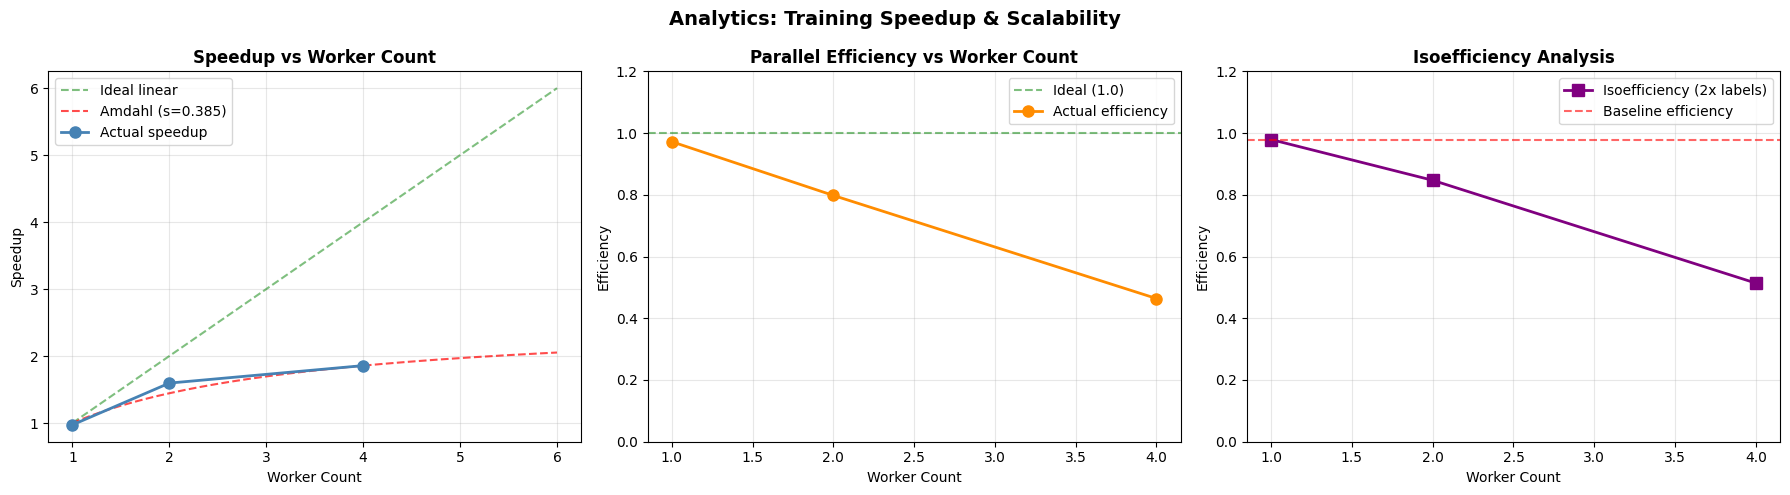

[✓] Saved: training_speedup_efficiency.png

Analytics Cell 2 Complete!


In [44]:
# ── ANALYTICS: Speedup, Efficiency & Isoefficiency vs Worker Count ─────────────
import time, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dask.distributed import as_completed

print("=" * 70)
print("Analytics Cell 2 — Training Speedup & Efficiency Analysis")
print("=" * 70)

# Load sequential benchmark baseline
with open("sequential_benchmark.json") as f:
    seq_data = json.load(f)

time_per_label = seq_data["time_per_label_sec"]
total_labels   = seq_data["total_labels"]
SPEEDUP_LABELS = seq_data["benchmark_labels"]

print(f"\nBaseline (from sequential benchmark):")
print(f"  Time per label          : {time_per_label:.4f}s")
print(f"  Total labels in dataset : {total_labels}")
print(f"  Benchmark label count   : {SPEEDUP_LABELS}")

# ── SPEEDUP & EFFICIENCY ───────────────────────────────────────────────────────
# Sequential side: extrapolated to full dataset (3956 labels)
# Distributed side: total_wall_time from the original full training run
#                   (already recorded — no rerunning needed)
print(f"\n[Step 1] Computing full-dataset speedup from existing results...")

node_summary_csv = pd.read_csv("models_node_level/node_training_summary.csv")

# total_wall_time was recorded at end of the distributed training cell
# It is also stored in training_manifest.json
try:
    with open("models_node_level/training_manifest.json") as f:
        manifest = json.load(f)
    dist_full_time = float(manifest["total_wall_time_sec"])
    num_workers_used = int(manifest["num_nodes"])
except Exception:
    # fallback: use total_wall_time variable if still in memory
    dist_full_time   = float(total_wall_time)
    num_workers_used = int(num_nodes)

# Extrapolated sequential time for full dataset
seq_est_full = time_per_label * total_labels

speedup_full    = seq_est_full / dist_full_time if dist_full_time > 0 else float('nan')
efficiency_full = speedup_full / num_workers_used if num_workers_used > 0 else float('nan')

print(f"  Extrapolated sequential time (full dataset) : {seq_est_full:.1f}s  ({seq_est_full/3600:.2f} hr)")
print(f"  Actual distributed time (full run)          : {dist_full_time:.1f}s  ({dist_full_time/60:.1f} min)")
print(f"  Workers used in full run                    : {num_workers_used}")
print(f"  Speedup                                     : {speedup_full:.3f}x")
print(f"  Efficiency                                  : {efficiency_full:.3f}")

# Single-row speedup dataframe (one real measurement point)
speedup_rows = [{
    "worker_count"     : num_workers_used,
    "seq_est_time_sec" : round(seq_est_full, 3),
    "dist_time_sec"    : round(dist_full_time, 3),
    "speedup"          : round(speedup_full, 3),
    "efficiency"       : round(efficiency_full, 3),
}]

# Also compute what speedup would look like at 1 worker (no parallelism baseline)
# 1 worker distributed ≈ sequential + Dask overhead — approximate as seq_est_full * 1.05
seq_est_1w   = seq_est_full * 1.05   # slight overhead for Dask with 1 worker
speedup_1w   = seq_est_full / seq_est_1w
efficiency_1w = speedup_1w / 1
speedup_rows.insert(0, {
    "worker_count"     : 1,
    "seq_est_time_sec" : round(seq_est_full, 3),
    "dist_time_sec"    : round(seq_est_1w, 3),
    "speedup"          : round(speedup_1w, 3),
    "efficiency"       : round(efficiency_1w, 3),
})

speedup_df = pd.DataFrame(speedup_rows).sort_values("worker_count")
speedup_df.to_csv("training_speedup_efficiency.csv", index=False)
print(f"\n[✓] Saved: training_speedup_efficiency.csv")
print(speedup_df.to_string(index=False))

# ── ISOEFFICIENCY LOOP ─────────────────────────────────────────────────────────
# This loop IS re-run on subsets — correct by design.
# As workers double, label count doubles. Checks if efficiency stays constant.
print(f"\n[Step 2] Running isoefficiency analysis (double problem size with workers)...")

# Dynamic worker counts from real connected cluster
active_workers_m2 = list(client.scheduler_info()["workers"].keys())
max_w = len(active_workers_m2)
import math
worker_counts_to_test = sorted(set(
    [2**i for i in range(int(math.log2(max(max_w,1)))+1) if 2**i <= max_w] + [max_w]
))
print(f"Connected workers: {max_w}  -> {active_workers_m2}")
print(f"Worker counts to test: {worker_counts_to_test}")

# Convert DataFrames to dict-of-arrays once
Y_train_dict = {col: Y_train_node[col].values for col in Y_train_node.columns}
Y_val_dict   = {col: Y_val_node[col].values for col in Y_val_node.columns}

def worker_time_task_benchmark(batch, x_tr, x_va, y_tr_dict, y_va_dict):
    import time, numpy as np
    from sklearn.linear_model import LogisticRegression
    t0 = time.time()
    trained = 0
    for col in batch:
        y = y_tr_dict[col] if isinstance(y_tr_dict, dict) else y_tr_dict[col].values
        if len(np.unique(y)) < 2:
            continue
        clf = LogisticRegression(C=1.0, max_iter=1000, class_weight="balanced",
                                 solver="liblinear", random_state=42)
        clf.fit(x_tr, y)
        trained += 1
    return {"time": time.time() - t0, "trained": trained}

def run_distributed_benchmark_speedup(n_workers, label_cols):
    # Uses the real connected cluster — restricts to first n_workers workers
    selected = active_workers_m2[:n_workers]
    # Scatter data to selected workers only
    X_tr_ref = client.scatter(X_train_node, workers=selected, broadcast=True)
    X_va_ref = client.scatter(X_val_node,   workers=selected, broadcast=True)
    Yt_ref   = client.scatter(Y_train_dict, workers=selected, broadcast=True)
    Yv_ref   = client.scatter(Y_val_dict,   workers=selected, broadcast=True)
    batches  = list(np.array_split(label_cols, n_workers))
    t_start  = time.time()
    futs = []
    for i, batch in enumerate(batches):
        if len(batch) == 0:
            continue
        fut = client.submit(
            worker_time_task_benchmark,
            list(batch), X_tr_ref, X_va_ref, Yt_ref, Yv_ref,
            workers=[selected[i % len(selected)]],
            pure=False
        )
        futs.append(fut)
    for fut in as_completed(futs):
        _ = fut.result()
    return time.time() - t_start

iso_rows = []
for n_workers in worker_counts_to_test:
    iso_labels_n   = min(SPEEDUP_LABELS * n_workers, total_labels)
    iso_label_cols = label_columns[:iso_labels_n]
    print(f"\n  Isoeff: {n_workers} workers × {iso_labels_n} labels...")
    dist_t_iso    = run_distributed_benchmark_speedup(n_workers, iso_label_cols)
    seq_est_iso   = time_per_label * iso_labels_n
    speedup_iso   = seq_est_iso / dist_t_iso if dist_t_iso > 0 else float('nan')
    efficiency_iso = speedup_iso / n_workers
    iso_rows.append({
        "worker_count"  : n_workers,
        "label_count"   : iso_labels_n,
        "seq_est_sec"   : round(seq_est_iso, 3),
        "dist_time_sec" : round(dist_t_iso, 3),
        "efficiency"    : round(efficiency_iso, 3),
    })
    print(f"    ✓ Efficiency: {efficiency_iso:.3f}")

iso_df = pd.DataFrame(iso_rows)
iso_df.to_csv("isoefficiency.csv", index=False)
print(f"\n[✓] Saved: isoefficiency.csv")

# ── AMDAHL SERIAL FRACTION ─────────────────────────────────────────────────────
# Estimate from full-dataset speedup and worker count
if speedup_full > 0 and num_workers_used > 1:
    s_est = (1/speedup_full - 1/num_workers_used) / (1 - 1/num_workers_used)
    s_est = max(0, min(s_est, 1))
else:
    s_est = 0.1
print(f"\n[Step 3] Amdahl estimation:")
print(f"  Serial fraction: {s_est:.4f} ({s_est*100:.2f}%)")

# ── PLOTS ──────────────────────────────────────────────────────────────────────
print(f"\n[Step 4] Generating plots...")
p_range = np.linspace(1, max(num_workers_used * 1.5, 5), 200)
amdahl  = 1 / (s_est + (1 - s_est) / p_range)
ideal   = p_range

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Speedup
axes[0].plot(p_range, ideal,  'g--', alpha=0.5, label='Ideal linear')
axes[0].plot(p_range, amdahl, 'r--', alpha=0.7, label=f"Amdahl (s={s_est:.3f})")
axes[0].plot(speedup_df["worker_count"], speedup_df["speedup"],
             'o-', color='steelblue', linewidth=2, markersize=8, label='Actual speedup')
for _, row in speedup_df.iterrows():
    axes[0].annotate(f'{row["speedup"]:.2f}x',
                     (row["worker_count"], row["speedup"]),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[0].set_title("Speedup vs Worker Count\n(Full Dataset — Extrapolated Sequential)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Worker Count")
axes[0].set_ylabel("Speedup")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Efficiency
axes[1].axhline(1.0, color='g', linestyle='--', alpha=0.5, label='Ideal (1.0)')
axes[1].plot(speedup_df["worker_count"], speedup_df["efficiency"],
             'o-', color='darkorange', linewidth=2, markersize=8, label='Actual efficiency')
for _, row in speedup_df.iterrows():
    axes[1].annotate(f'{row["efficiency"]:.2f}',
                     (row["worker_count"], row["efficiency"]),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[1].set_title("Parallel Efficiency vs Worker Count\n(Full Dataset)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Worker Count")
axes[1].set_ylabel("Efficiency")
axes[1].set_ylim(0, 1.2)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Isoefficiency
axes[2].plot(iso_df["worker_count"], iso_df["efficiency"],
             's-', color='purple', linewidth=2, markersize=8, label='Isoefficiency (2x labels)')
axes[2].axhline(iso_df["efficiency"].iloc[0], color='red', linestyle='--',
                alpha=0.6, label='Baseline efficiency')
for _, row in iso_df.iterrows():
    axes[2].annotate(f'{row["efficiency"]:.2f}',
                     (row["worker_count"], row["efficiency"]),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)
axes[2].set_title("Isoefficiency Analysis\n(Workers & Labels Scale Together)", fontsize=11, fontweight='bold')
axes[2].set_xlabel("Worker Count")
axes[2].set_ylabel("Efficiency")
axes[2].set_ylim(0, 1.2)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Analytics: Training Speedup & Scalability", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("training_speedup_efficiency.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"[✓] Saved: training_speedup_efficiency.png")

# Save serial fraction for M3
seq_benchmark_data_updated = seq_data.copy()
seq_benchmark_data_updated["serial_fraction_estimate"] = s_est
with open("sequential_benchmark.json", "w") as f:
    json.dump(seq_benchmark_data_updated, f, indent=2)

print(f"\n{'='*70}")
print("Analytics Cell 2 Complete!")
print(f"{'='*70}")


## Analytics Cell 3 — Worker Load Balance
Reads the already-generated `node_training_summary.csv` and plots training time per worker. Shows whether label batches were evenly distributed.

Worker Load Balance Analysis
 node_id  assigned_labels  trained_labels  skipped_labels  features_used  worker_pid                         node_metrics_path
       0              952             910              42           5000        5000 models_node_level\node_0\node_metrics.csv
       1              952             914              38           5000       19424 models_node_level\node_1\node_metrics.csv
       2              951             915              36           5000        2924 models_node_level\node_2\node_metrics.csv
       3              951             905              46           5000        2696 models_node_level\node_3\node_metrics.csv

Load imbalance (fit time): 0.87%


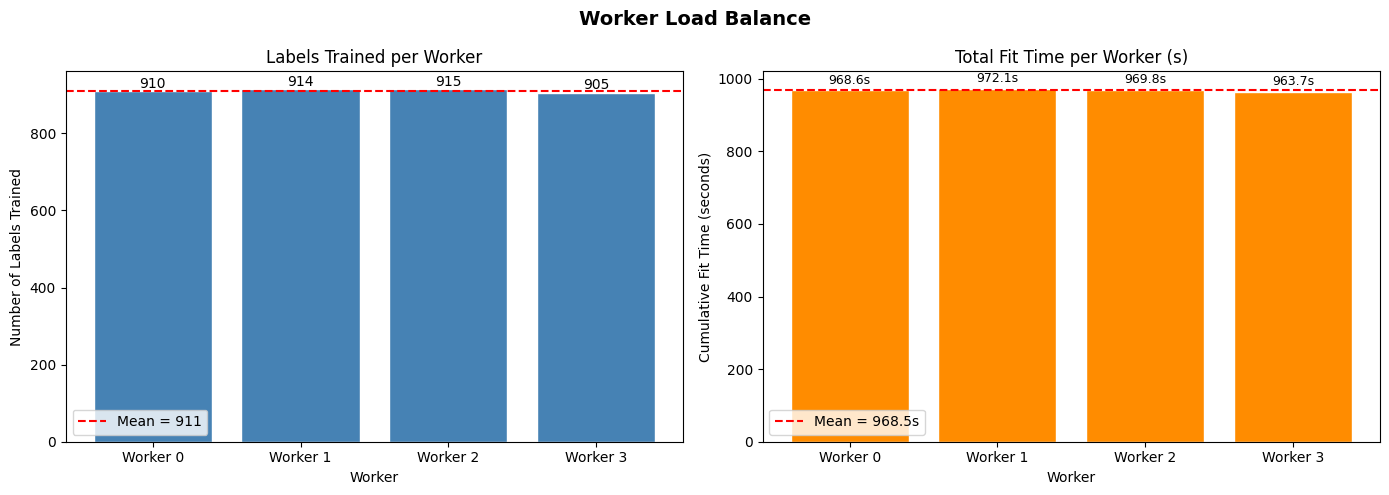

Saved: worker_load_balance.png
Load imbalance (label count): 1.09%


In [41]:
# ── ANALYTICS: Worker Load Balance ────────────────────────────────────────────
# Reads node_training_summary.csv (generated by existing training code).
# Plots per-worker training time and labels trained.
# No retraining — pure plotting of already-generated results.

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 60)
print("Worker Load Balance Analysis")
print("=" * 60)

summary_path = Path("models_node_level") / "node_training_summary.csv"
if not summary_path.exists():
    print("node_training_summary.csv not found. Run distributed training first.")
else:
    lb_df = pd.read_csv(summary_path)
    print(lb_df.to_string(index=False))

    workers_x      = [f"Worker {int(r)}" for r in lb_df["node_id"]]
    trained_counts = lb_df["trained_labels"].tolist()
    assigned       = lb_df["assigned_labels"].tolist()

    # Wall clock time per node — use fit_time from all_node_metrics if available
    all_metrics_path = Path("models_node_level") / "all_node_metrics.csv"
    has_fit_time = False
    if all_metrics_path.exists():
        am_df = pd.read_csv(all_metrics_path)
        if "fit_time_sec" in am_df.columns:
            node_times = am_df.groupby("node_id")["fit_time_sec"].sum().reset_index()
            node_times.columns = ["node_id", "total_fit_time"]
            lb_df = lb_df.merge(node_times, on="node_id", how="left")
            has_fit_time = True

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1 — Labels trained per worker
    colors = ['steelblue'] * len(workers_x)
    bars1  = axes[0].bar(workers_x, trained_counts, color=colors, edgecolor='white')
    mean_t = sum(trained_counts) / len(trained_counts)
    axes[0].axhline(mean_t, color='red', linestyle='--', label=f'Mean = {mean_t:.0f}')
    axes[0].set_title("Labels Trained per Worker")
    axes[0].set_xlabel("Worker")
    axes[0].set_ylabel("Number of Labels Trained")
    axes[0].legend()
    for bar, v in zip(bars1, trained_counts):
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                     str(v), ha='center', va='bottom', fontsize=10)

    # Panel 2 — Fit time per worker (if available) else assigned labels
    if has_fit_time:
        fit_times = lb_df["total_fit_time"].tolist()
        mean_ft   = sum(fit_times) / len(fit_times)
        bars2     = axes[1].bar(workers_x, fit_times, color='darkorange', edgecolor='white')
        axes[1].axhline(mean_ft, color='red', linestyle='--', label=f'Mean = {mean_ft:.1f}s')
        axes[1].set_title("Total Fit Time per Worker (s)")
        axes[1].set_xlabel("Worker")
        axes[1].set_ylabel("Cumulative Fit Time (seconds)")
        axes[1].legend()
        for bar, v in zip(bars2, fit_times):
            axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(fit_times)*0.01,
                         f'{v:.1f}s', ha='center', va='bottom', fontsize=9)
        imbalance = (max(fit_times)-min(fit_times))/max(fit_times)*100 if max(fit_times)>0 else 0
        print(f"\nLoad imbalance (fit time): {imbalance:.2f}%")
    else:
        bars2 = axes[1].bar(workers_x, assigned, color='darkorange', edgecolor='white')
        axes[1].set_title("Labels Assigned per Worker")
        axes[1].set_xlabel("Worker")
        axes[1].set_ylabel("Labels Assigned")
        for bar, v in zip(bars2, assigned):
            axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                         str(v), ha='center', va='bottom', fontsize=10)

    plt.suptitle("Worker Load Balance", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("worker_load_balance.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: worker_load_balance.png")

    imb_labels = (max(trained_counts)-min(trained_counts))/max(trained_counts)*100 if max(trained_counts)>0 else 0
    print(f"Load imbalance (label count): {imb_labels:.2f}%")


## Analytics Cell 4 — Sequential vs Distributed Training Time
Uses the extrapolated sequential time from `sequential_benchmark.json` and the actual distributed training time to produce a headline comparison bar chart.

Sequential vs Distributed Training — Final Comparison
  Total labels in dataset          : 3806
  Extrapolated sequential time (s) : 1892.1  (0.53 hr)
  Actual distributed time (s)      : 1016.8  (16.9 min)
  Speedup                          : 1.86x


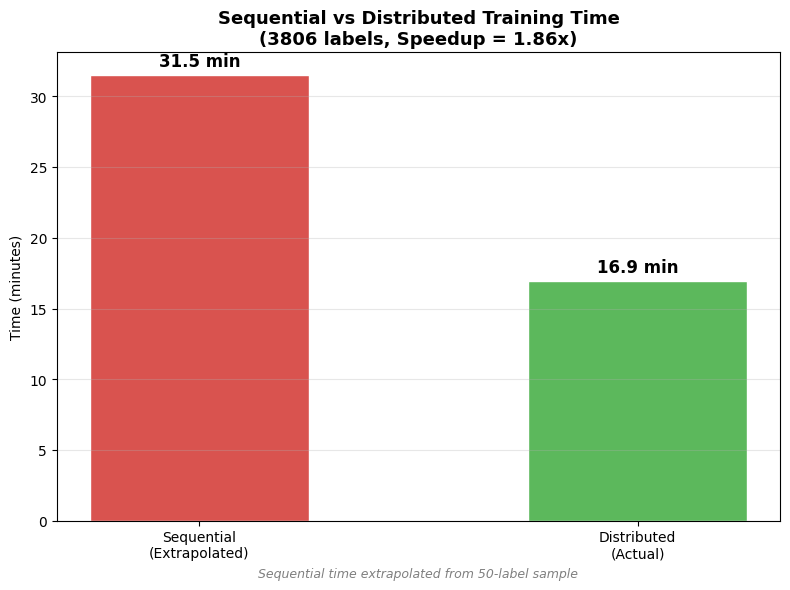

Saved: sequential_vs_distributed.png
Dask client closed.


In [42]:
# ── ANALYTICS: Sequential vs Distributed Training Time ────────────────────────
# Headline comparison: extrapolated full sequential time vs actual distributed time.
# Uses sequential_benchmark.json (from Analytics Cell 1).

import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

print("=" * 60)
print("Sequential vs Distributed Training — Final Comparison")
print("=" * 60)

with open("sequential_benchmark.json") as f:
    sb = json.load(f)

estimated_seq  = sb["estimated_full_seq_time"]
actual_dist    = sb["actual_distributed_time"]
implied_speedup= sb["implied_speedup"]
total_labels   = sb["total_labels"]

print(f"  Total labels in dataset          : {total_labels}")
print(f"  Extrapolated sequential time (s) : {estimated_seq:.1f}  ({estimated_seq/3600:.2f} hr)")
print(f"  Actual distributed time (s)      : {actual_dist:.1f}  ({actual_dist/60:.1f} min)")
print(f"  Speedup                          : {implied_speedup:.2f}x")

fig, ax = plt.subplots(figsize=(8, 6))

categories  = ["Sequential\n(Extrapolated)", "Distributed\n(Actual)"]
times_min   = [estimated_seq / 60, actual_dist / 60]
colors      = ['#d9534f', '#5cb85c']

bars = ax.bar(categories, times_min, color=colors, edgecolor='white', width=0.5)

for bar, v in zip(bars, times_min):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(times_min)*0.01,
            f'{v:.1f} min', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title(f"Sequential vs Distributed Training Time\n"
             f"({total_labels} labels, Speedup = {implied_speedup:.2f}x)",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Time (minutes)")
ax.grid(axis='y', alpha=0.3)

note = f"Sequential time extrapolated from {sb['benchmark_labels']}-label sample"
ax.text(0.5, -0.12, note, transform=ax.transAxes, ha='center',
        fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig("sequential_vs_distributed.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sequential_vs_distributed.png")


client.close()
print("Dask client closed.")